*Jakub Kobus 283969*
# Sprawozdanie z algorytmów metaheurystycznych (Lista 3)
## Algorytm Genetyczny (GA)

### Opis działania algorytmu

**Generowanie populacji początkowej:**
Każdy osobnik to losowa permutacja wierzchołków (trasa przechodząca przez wszystkie miasta).
Populacja początkowa jest generowana poprzez wielokrotne losowe przetasowanie trasy bazowej.

**Selekcja:**
Zastosowałem selekcję turniejową (tournament selection) z parametrem $k = 3$.
Losuję $k$ osobników z populacji i wybieram najlepszego (najmniejsza długość trasy).

**Krzyżowanie:**
Porównałem dwa operatory:
* **OX (Order Crossover)** – wybiera losowy fragment z rodzica 1, a pozostałe pozycje wypełnia wartościami z rodzica 2 w kolejności ich wystąpienia.
* **PMX (Partially Mapped Crossover)** – wybiera losowy fragment z rodzica 1, a dla pozostałych pozycji mapuje wartości z rodzica 2 przez relację mapowania wyznaczoną przez fragment.

**Mutacja:**
Zastosowałem mutację przez odwracanie (invert mutation) – z pewnym prawdopodobieństwem wybieram dwa punkty na chromosomie i odwracam segment między nimi.

**Warunek stopu:**
Algorytm zatrzymuje się po osiągnięciu zadanej liczby pokoleń.

**Zrównoleglenie:**
Wykorzystałem OpenMP do zrównoleglenia ewaluacji populacji początkowej oraz generowania nowej populacji w każdym pokoleniu.

## Eksperymenty

Przeprowadzono parametryzację algorytmu na małych instancjach <1000 wierzchołków.
Dla każdej kombinacji parametrów wykonałem 100 uruchomień i uśredniłem wyniki.

**Badane parametry:**
* Rozmiar populacji: 50, 100, 200
* Prawdopodobieństwo krzyżowania: 0.7, 0.8, 0.9
* Prawdopodobieństwo mutacji: 0.01, 0.05, 0.1
* Operator krzyżowania: OX, PMX

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from pathlib import Path

sns.set_theme(style="whitegrid")

root = Path.cwd()
if root.name == "analysis":
    root = root.parent
csv_path = root / "results" / "experiments.csv"

df = pd.read_csv(csv_path)

df.rename(columns={
    "instance": "file",
    "pop_size": "popSize",
    "cross_rate": "cxRate",
    "mut_rate": "mutRate",
    "cx_type": "cxType",
    "avg_best_dist": "avgLength",
    "time_seconds": "time",
}, inplace=True)

display(df.head(10))

,file,popSize,cxRate,mutRate,cxType,avgLength,time
0,wi29,50,0.7,0.01,OX,36281.3,0.006367
1,wi29,50,0.7,0.05,OX,30872.7,0.005982
2,wi29,50,0.7,0.10,OX,29412.8,0.007581
3,wi29,50,0.8,0.01,OX,38572.9,0.008435
4,wi29,50,0.8,0.05,OX,30996.3,0.007104
5,wi29,50,0.8,0.10,OX,28882.7,0.007374
6,wi29,50,0.9,0.01,OX,36679.4,0.009129
7,wi29,50,0.9,0.05,OX,29416.0,0.007501
8,wi29,50,0.9,0.10,OX,28973.1,0.009123
9,wi29,100,0.7,0.01,OX,34209.8,0.015840


In [6]:
def getN(filename):
    match = re.search(r"(\d+)", filename)
    return int(match.group(1)) if match else 1

df['N'] = df["file"].apply(getN)
df = df.sort_values('N')

globalBest = df.groupby('file')['avgLength'].min()
df['error'] = (df['avgLength'] - df['file'].map(globalBest)) / df['file'].map(globalBest) * 100

display(df[['file', 'N', 'popSize', 'cxRate', 'mutRate', 'cxType', 'avgLength', 'error']].head())

,file,N,popSize,cxRate,mutRate,cxType,avgLength,error
0,wi29,29,50,0.7,0.01,OX,36281.3,28.266834
1,wi29,29,50,0.7,0.05,OX,30872.7,9.145578
2,wi29,29,50,0.7,0.10,OX,29412.8,3.984331
3,wi29,29,50,0.8,0.01,OX,38572.9,36.368425
4,wi29,29,50,0.8,0.05,OX,30996.3,9.582547


## Analiza wpływu parametrów na błąd względny

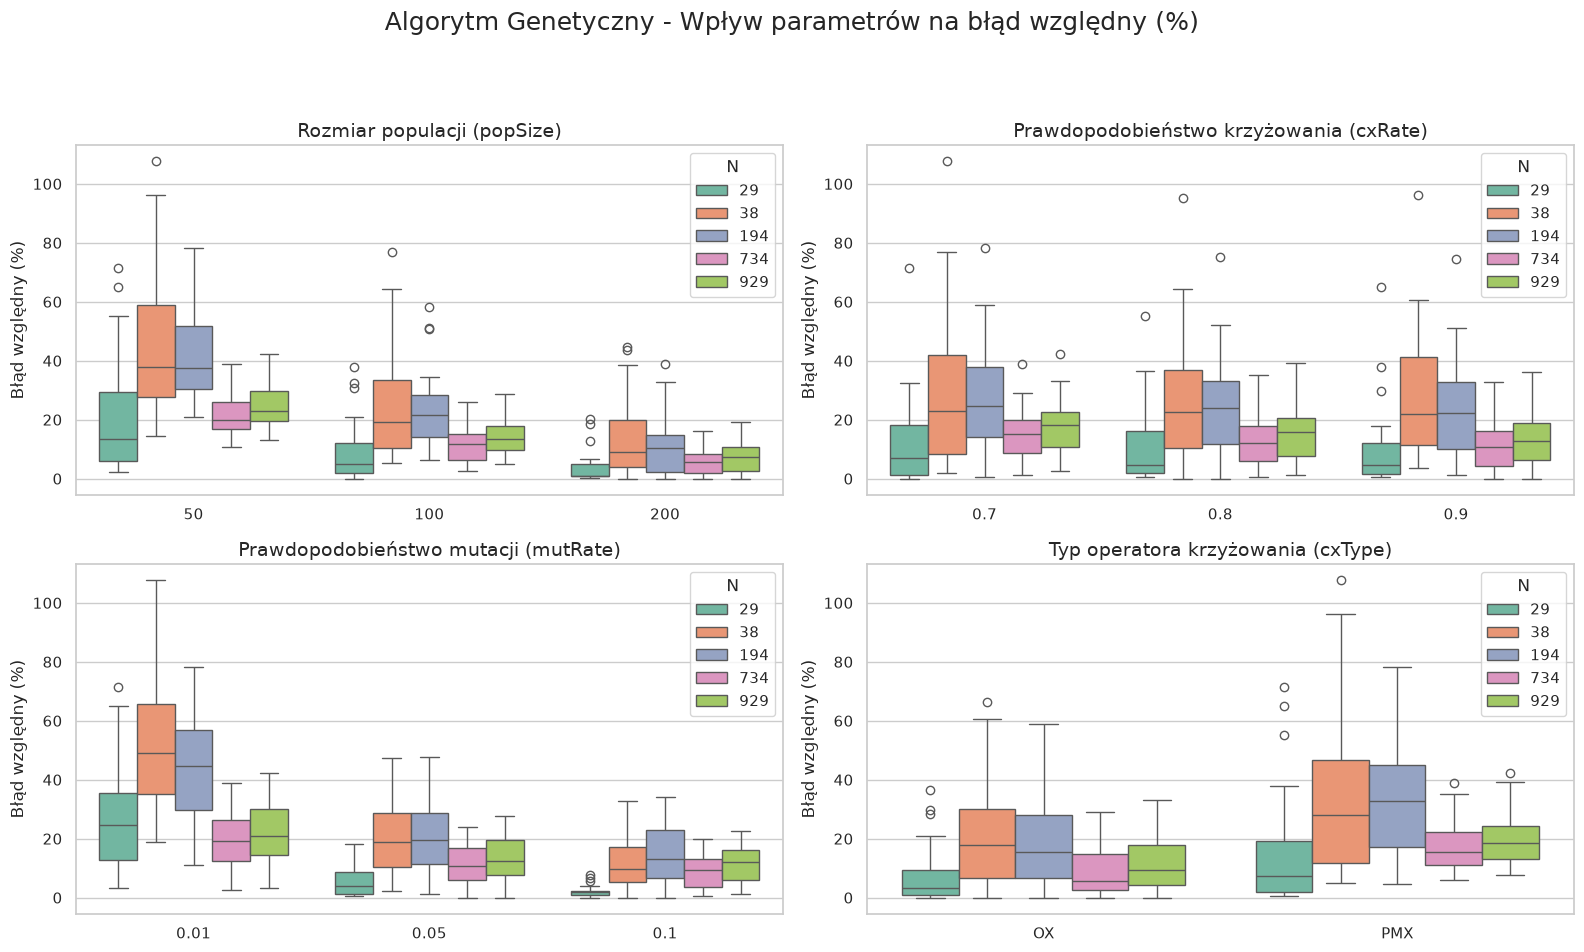

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Algorytm Genetyczny - Wpływ parametrów na błąd względny (%)", fontsize=18)

sns.boxplot(data=df, x="popSize", y="error", hue='N', ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Rozmiar populacji (popSize)", fontsize=14)

sns.boxplot(data=df, x="cxRate", y="error", hue='N', ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Prawdopodobieństwo krzyżowania (cxRate)", fontsize=14)

sns.boxplot(data=df, x="mutRate", y="error", hue='N', ax=axes[1,0], palette="Set2")
axes[1,0].set_title("Prawdopodobieństwo mutacji (mutRate)", fontsize=14)

sns.boxplot(data=df, x="cxType", y="error", hue='N', ax=axes[1,1], palette="Set2")
axes[1,1].set_title("Typ operatora krzyżowania (cxType)", fontsize=14)

for ax in axes.flat:
    ax.set_xlabel('')
    if ax.get_visible():
        ax.set_ylabel('Błąd względny (%)')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

In [8]:
bestIdx = df.groupby('file')['error'].idxmin()
bestTable = df.loc[bestIdx, ['file', 'N', 'popSize', 'cxRate', 'mutRate', 'cxType', 'avgLength', 'error']]
display(bestTable.style.hide(axis='index'))

file,N,popSize,cxRate,mutRate,cxType,avgLength,error
dj38,38,200,0.800000,0.100000,OX,6965.640000,0.000000
qa194,194,200,0.800000,0.100000,OX,31409.700000,0.000000
uy734,734,200,0.900000,0.050000,OX,955757.000000,0.000000
wi29,29,100,0.700000,0.100000,OX,28285.800000,0.000000
zi929,929,200,0.900000,0.050000,OX,1336530.000000,0.000000


In [9]:
combo_error = df.groupby(['popSize', 'cxRate', 'mutRate', 'cxType'])['error'].mean().reset_index()
bestGlobal = combo_error.loc[combo_error['error'].idxmin()]

print("=" * 60)
print("NAJLEPSZE PARAMETRY (najniższy średni błąd względny):")
print(f"  cx_type   = {bestGlobal['cxType']}")
print(f"  pop_size  = {int(bestGlobal['popSize'])}")
print(f"  cross_rate= {bestGlobal['cxRate']}")
print(f"  mut_rate  = {bestGlobal['mutRate']}")
print(f"  mean_err  = {bestGlobal['error']:.2f}%")
print("=" * 60)

best = {
    "cx_type": bestGlobal['cxType'],
    "pop_size": int(bestGlobal['popSize']),
    "cross_rate": bestGlobal['cxRate'],
    "mut_rate": bestGlobal['mutRate'],
    "mean_rel_error_pct": round(bestGlobal['error'], 2),
}

NAJLEPSZE PARAMETRY (najniższy średni błąd względny):
  cx_type   = OX
  pop_size  = 200
  cross_rate= 0.8
  mut_rate  = 0.1
  mean_err  = 0.44%


**Ostateczne parametry:**
* `populationSize` = 200
* `crossoverRate` = 0.8
* `mutationRate` = 0.1
* `crossoverType` = OX